<a href="https://colab.research.google.com/github/MKdentist/deep-learning-course/blob/main/Ethnicity_Age_Gender_efficientnet_and_inception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("mkk")

print("Kaggle credentials loaded from Colab secrets.")


Kaggle credentials loaded from Colab secrets.


In [3]:
!kaggle datasets download -d jangedoo/utkface-new -p /content --force


Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:16<00:00, 20.8MB/s]



In [4]:
zip_path = "/content/utkface-new.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")


Dataset extracted successfully.


In [5]:
folder_path = Path("/content/utkface_aligned_cropped/UTKFace")

print("Folder exists:", folder_path.exists())
print("Total files:", len(list(folder_path.glob("*.jpg"))))


Folder exists: True
Total files: 23708


In [6]:
import os

extracted_dataset_path = "/content/utkface_aligned_cropped/UTKFace"

# List contents of the extracted directory
print("Contents of the extracted dataset:")
for root, dirs, files in os.walk(extracted_dataset_path):
    level = root.replace(extracted_dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Contents of the extracted dataset:
UTKFace/
    54_1_0_20170103183730785.jpg.chip.jpg
    28_0_3_20170119194935947.jpg.chip.jpg
    65_0_0_20170104184048158.jpg.chip.jpg
    57_0_3_20170119211459705.jpg.chip.jpg
    26_0_1_20170117200522916.jpg.chip.jpg
    35_1_0_20170117203321066.jpg.chip.jpg
    23_1_0_20170103233631243.jpg.chip.jpg
    55_0_3_20170119204811925.jpg.chip.jpg
    28_1_0_20170117183207853.jpg.chip.jpg
    4_1_3_20161219224833967.jpg.chip.jpg
    78_0_0_20170111222546535.jpg.chip.jpg
    26_1_2_20170116184707239.jpg.chip.jpg
    32_0_0_20170117091009872.jpg.chip.jpg
    69_0_0_20170109011208585.jpg.chip.jpg
    67_0_0_20170113185521375.jpg.chip.jpg
    26_1_2_20170116184443484.jpg.chip.jpg
    82_0_0_20170111210717906.jpg.chip.jpg
    42_1_0_20170104181529757.jpg.chip.jpg
    24_1_2_20170116174612535.jpg.chip.jpg
    34_0_0_20170117182644198.jpg.chip.jpg
    70_0_0_20170111210749134.jpg.chip.jpg
    28_1_0_20170112235141673.jpg.chip.jpg
    3_1_0_20170109190717071.jpg.c

In [7]:
records = []

for img_file in folder_path.glob("*.jpg"):
    try:
        parts = img_file.name.split("_")
        age = int(parts[0])
        gender = int(parts[1])
        ethnicity = int (parts[2])

        if gender in [0, 1] and 1 <= age <= 116 and ethnicity in [0,1,2,3,4]:
            records.append({
                "image_path": str(img_file),
                "age": age,
                "gender": gender,
                "race": ethnicity
            })
    except Exception:
        continue

df = pd.DataFrame(records)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (23705, 4)


,image_path,age,gender,race
0,/content/utkface_aligned_cropped/UTKFace/54_1_...,54,1,0
1,/content/utkface_aligned_cropped/UTKFace/28_0_...,28,0,3
2,/content/utkface_aligned_cropped/UTKFace/65_0_...,65,0,0
3,/content/utkface_aligned_cropped/UTKFace/57_0_...,57,0,3
4,/content/utkface_aligned_cropped/UTKFace/26_0_...,26,0,1


Gender distribution:
gender
0    12391
1    11314
Name: count, dtype: int64


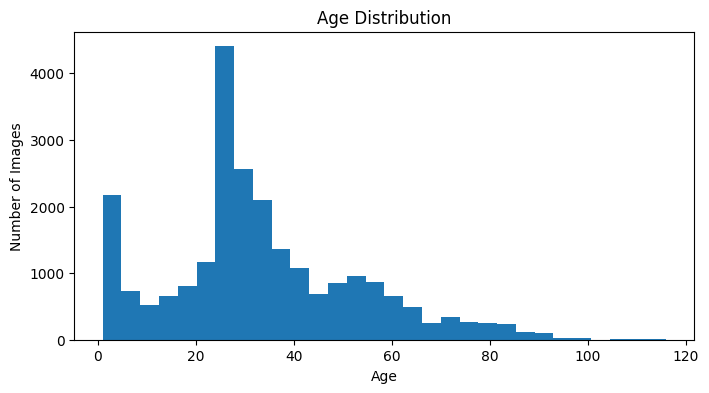

race distribution:
race
0    10078
1     4526
3     3975
2     3434
4     1692
Name: count, dtype: int64


In [8]:
print("Gender distribution:")
print(df["gender"].value_counts())

plt.figure(figsize=(8, 4))
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")
plt.show()
print("race distribution:")
print(df["race"].value_counts())

## Cell 8: Split Data into Training and Validation Sets

We use 80% data for training and 20% for validation.


In [9]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df["gender"]
)

print("Training samples:", train_df.shape)
print("Validation samples:", val_df.shape)


Training samples: (18964, 4)
Validation samples: (4741, 4)


## Cell 9: Create TensorFlow Dataset Pipeline

This modern `tf.data` pipeline avoids the old `ImageDataGenerator` multi-output problem.

For each image, it returns:

```python
image, {"age": age_label, "gender": gender_label}
```

This structure exactly matches our model outputs.


In [10]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_image_and_labels(image_path, age, gender, race):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)

    labels = {
        "age": tf.cast(age, tf.float32),
        "gender": tf.cast(gender, tf.float32),
         "race": tf.cast(race, tf.float32)
    }

    return image, labels


def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    ages = dataframe["age"].values
    genders = dataframe["gender"].values
    races = dataframe["race"].values # Changed variable name to avoid conflict with function param

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, ages, genders, races))
    dataset = dataset.map(load_image_and_labels, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [11]:
race_labels = {
    0: 'White',
    1: 'Black',
    2: 'Asian',
    3: 'Indian',
    4: 'Others' # (like Hispanic, Latino, Middle Eastern)
}

print("Race Labels:", race_labels)

Race Labels: {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}


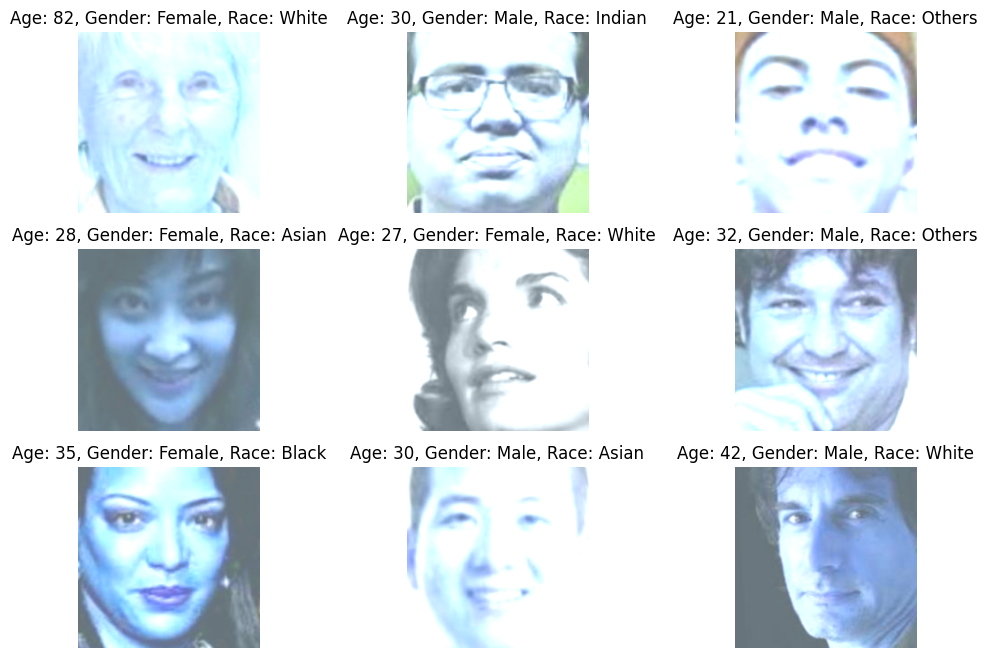

In [12]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 8))
    for i in range(9):
        img = images[i].numpy()
        # Reverse ResNet preprocessing approximately for display
        img = img[..., ::-1]
        img = img + np.array([103.939, 116.779, 123.68])
        img = np.clip(img, 0, 255).astype("uint8")

        age = int(labels["age"][i].numpy())
        gender = int(labels["gender"][i].numpy())
        gender_name = "Female" if gender == 1 else "Male"
        race = int(labels["race"][i].numpy())
        race_name = race_labels.get(race, "Unknown") # Use the race_labels dictionary

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Age: {age}, Gender: {gender_name}, Race: {race_name}")
        plt.axis("off")
    plt.show()

In [13]:
base_model = EfficientNetB2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

age_output = layers.Dense(1, activation="linear", name="age")(x)
gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)
race_output = layers.Dense(5, activation="softmax", name="race")(x)

model = Model(inputs=inputs, outputs={"age": age_output, "gender": gender_output,"race": race_output})

model.summary()


31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb2      │ (None, 7, 7,      │  7,768,569 │ input_layer_1[0]… │
│ (Functional)        │ 1408)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1408)      │          0 │ efficientnetb2[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    721,408 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        257 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        257 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ race (Dense)        │ (None, 5)         │      1,285 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,623,104 (32.89 MB)

 Trainable params: 854,535 (3.26 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

## Cell 12: Compile the Model

The model uses two losses:

1. **Age loss**: Mean Absolute Error because age is a regression problem.
2. **Gender loss**: Binary Crossentropy because gender is binary classification.

We also use loss weights so that gender learning is not ignored.


In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy",
        "race": "sparse_categorical_crossentropy" # Corrected loss for race
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"],
        "race": ["sparse_categorical_accuracy"] # Added metric for race
    },
    loss_weights={
        "age": 1.0,
        "gender": 5.0,
        "race": 1.0 # Added loss weight for race
    }
)

## Cell 13: Define Callbacks

Callbacks help improve training:

- **EarlyStopping** stops training if validation loss stops improving.
- **ModelCheckpoint** saves the best model.
- **ReduceLROnPlateau** reduces learning rate when training becomes stuck.


In [31]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_efficientnetb2_age_gender_model.keras",
    monitor="val_loss",
    save_best_only=True
)

checkpoint_inception = ModelCheckpoint(
    "best_inceptionv3_age_gender_model.keras", # New checkpoint for InceptionV3
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 140s 162ms/step - age_loss: 12.7454 - age_mae: 12.7472 - gender_accuracy: 0.8018 - gender_loss: 0.4550 - loss: 16.8626 - race_loss: 1.8416 - race_sparse_categorical_accuracy: 0.3926 - val_age_loss: 9.0492 - val_age_mae: 9.0592 - val_gender_accuracy: 0.8604 - val_gender_loss: 0.3293 - val_loss: 11.8745 - val_race_loss: 1.1710 - val_race_sparse_categorical_accuracy: 0.5579 - learning_rate: 1.0000e-04
Epoch 2/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 47s 79ms/step - age_loss: 8.8996 - age_mae: 8.8997 - gender_accuracy: 0.8414 - gender_loss: 0.3687 - loss: 12.2469 - race_loss: 1.5042 - race_sparse_categorical_accuracy: 0.4790 - val_age_loss: 8.0781 - val_age_mae: 8.0941 - val_gender_accuracy: 0.8743 - val_gender_loss: 0.3104 - val_loss: 10.7135 - val_race_loss: 1.0706 - val_race_sparse_categorical_accuracy: 0.6041 - learning_rate: 1.0000e-04
Epoch 3/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 45s 74ms/step - age_loss: 8.3894 - age_mae: 8.3905 - gender_accuracy: 0.8574 - gend

## Cell 15: Plot Training Curves

This cell plots age error and gender accuracy.


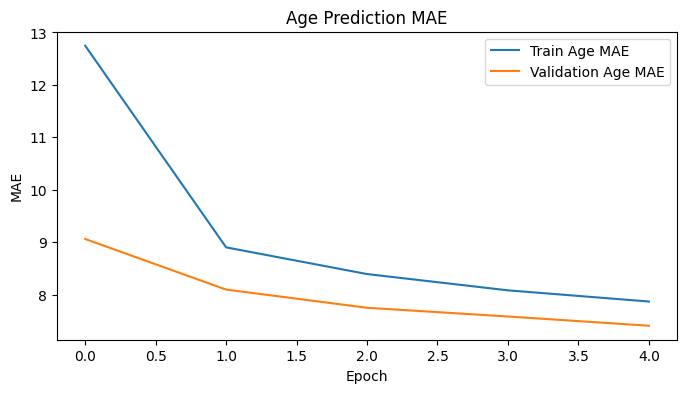

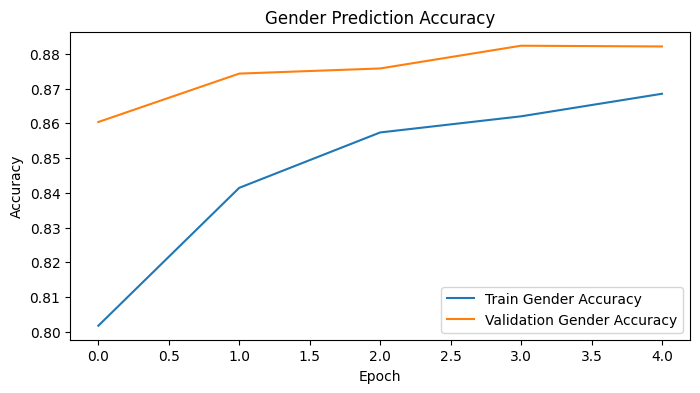

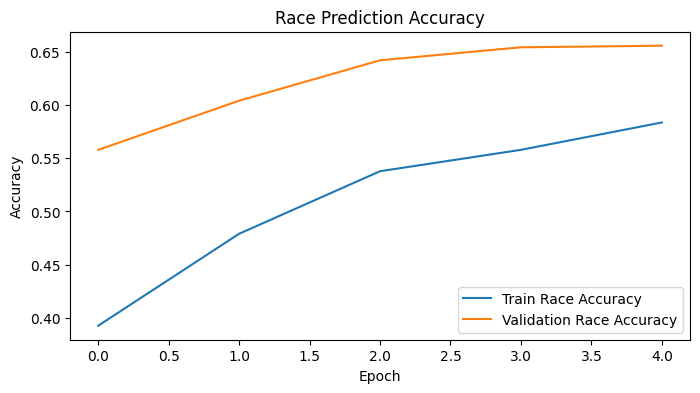

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["age_mae"], label="Train Age MAE")
plt.plot(history.history["val_age_mae"], label="Validation Age MAE")
plt.title("Age Prediction MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["gender_accuracy"], label="Train Gender Accuracy")
plt.plot(history.history["val_gender_accuracy"], label="Validation Gender Accuracy")
plt.title("Gender Prediction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["race_sparse_categorical_accuracy"], label="Train Race Accuracy")
plt.plot(history.history["val_race_sparse_categorical_accuracy"], label="Validation Race Accuracy")
plt.title("Race Prediction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [18]:
base_model.trainable = True

# Freeze earlier layers and fine-tune only last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy",
        "race": "sparse_categorical_crossentropy" # Added loss for race
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"],
        "race": ["sparse_categorical_accuracy"] # Added metric for race
    },
    loss_weights={
        "age": 1.0,
        "gender": 5.0,
        "race": 1.0 # Added loss weight for race
    }
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 128s 148ms/step - age_loss: 11.2227 - age_mae: 11.2256 - gender_accuracy: 0.7954 - gender_loss: 0.4319 - loss: 14.7907 - race_loss: 1.4050 - race_sparse_categorical_accuracy: 0.4748 - val_age_loss: 8.7224 - val_age_mae: 8.7304 - val_gender_accuracy: 0.8536 - val_gender_loss: 0.3367 - val_loss: 11.5366 - val_race_loss: 1.1267 - val_race_sparse_categorical_accuracy: 0.5741 - learning_rate: 1.0000e-05
Epoch 2/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 51s 84ms/step - age_loss: 9.0490 - age_mae: 9.0489 - gender_accuracy: 0.8349 - gender_loss: 0.3669 - loss: 12.2131 - race_loss: 1.3295 - race_sparse_categorical_accuracy: 0.5031 - val_age_loss: 8.0934 - val_age_mae: 8.1040 - val_gender_accuracy: 0.8652 - val_gender_loss: 0.3149 - val_loss: 10.7573 - val_race_loss: 1.0815 - val_race_sparse_categorical_accuracy: 0.5976 - learning_rate: 1.0000e-05
Epoch 3/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - age_loss: 8.5523 - age_mae: 8.5515 - gender_accuracy: 0.8511 - gend

## Cell 17: Evaluate the Model

This cell evaluates the final model on validation data.


In [43]:
import tensorflow as tf

# Load the best performing EfficientNetB2 model saved during training
# This ensures that we are evaluating the model with the best validation loss
model = tf.keras.models.load_model("best_efficientnetb2_age_gender_model.keras")

results = model.evaluate(val_ds)
print("Evaluation Results:", results)

149/149 ━━━━━━━━━━━━━━━━━━━━ 26s 93ms/step - age_loss: 20.6070 - age_mae: 20.5895 - gender_accuracy: 0.4784 - gender_loss: 0.6956 - loss: 25.5752 - race_loss: 1.5090 - race_sparse_categorical_accuracy: 0.4256
Evaluation Results: [25.575218200683594, 20.607023239135742, 0.6956031918525696, 1.5089675188064575, 20.589534759521484, 0.47838008403778076, 0.42564859986305237]


## Cell 18: Predict Age and Gender on One Image

Upload or give the path of any face image and run this function.


1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step


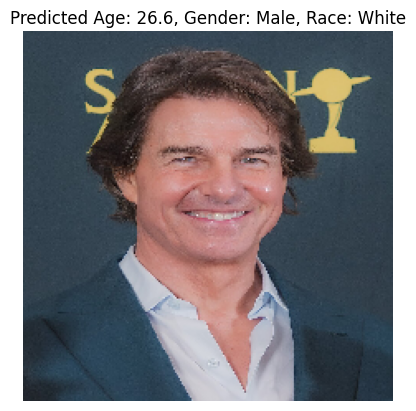

Predicted Age: 26.6
Predicted Gender: Male
Gender Probability Female: 0.149
Predicted Race: White
Race Probability: 0.578


In [20]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_age_gender(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    age = prediction["age"][0][0]
    gender_prob = prediction["gender"][0][0]
    gender = "Female" if gender_prob >= 0.5 else "Male"

    # Get race prediction
    race_probs = prediction["race"][0] # This will be an array of 5 probabilities
    predicted_race_idx = np.argmax(race_probs)
    predicted_race_label = race_labels.get(predicted_race_idx, "Unknown")
    max_race_prob = race_probs[predicted_race_idx]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted Age: {age:.1f}, Gender: {gender}, Race: {predicted_race_label}")
    plt.show()

    print(f"Predicted Age: {age:.1f}")
    print(f"Predicted Gender: {gender}")
    print(f"Gender Probability Female: {gender_prob:.3f}")
    print(f"Predicted Race: {predicted_race_label}")
    print(f"Race Probability: {max_race_prob:.3f}")


# Example:
predict_age_gender('/content/Tom_Cruise_at_53rd_Saturn_Awards_2026-01.jpg')

## Cell 19: Save Final Model

This saves the final trained model.


In [21]:
model.save("efficientnetb2_age_gender_final_model.keras")
print("Model saved successfully.")


Model saved successfully.


## Cell 20: Load Saved Model

Use this cell when you want to reuse the trained model later.


In [22]:
loaded_model = tf.keras.models.load_model("efficientnetb2_age_gender_final_model.keras")
print("Model loaded successfully.")


Model loaded successfully.


In [23]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [24]:
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

age_output = layers.Dense(1, activation="linear", name="age")(x)
gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)
race_output = layers.Dense(5, activation="softmax", name="race")(x)

I_model = Model(inputs=inputs, outputs={"age": age_output, "gender": gender_output,"race": race_output})

I_model.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_v3        │ (None, 5, 5,      │ 21,802,784 │ input_layer_3[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ inception_v3[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        257 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        257 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ race (Dense)        │ (None, 5)         │      1,285 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,984,999 (87.68 MB)

 Trainable params: 1,182,215 (4.51 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [25]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image_and_labels(image_path, age, gender, race):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image) # This now refers to InceptionV3.preprocess_input

    labels = {
        "age": tf.cast(age, tf.float32),
        "gender": tf.cast(gender, tf.float32),
         "race": tf.cast(race, tf.float32)
    }

    return image, labels


def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    ages = dataframe["age"].values
    genders = dataframe["gender"].values
    races = dataframe["race"].values # Changed variable name to avoid conflict with function param

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, ages, genders, races))
    dataset = dataset.map(load_image_and_labels, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

print("TensorFlow datasets created successfully with InceptionV3 preprocessing.")

TensorFlow datasets created successfully with InceptionV3 preprocessing.


In [32]:
I_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy",
        "race": "sparse_categorical_crossentropy" # Corrected loss for race
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"],
        "race": ["sparse_categorical_accuracy"] # Added metric for race
    },
    loss_weights={
        "age": 1.0,
        "gender": 5.0,
        "race": 1.0 # Added loss weight for race
    }
)

In [33]:
fine_tune_history_inception = I_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint_inception, reduce_lr] # Use inception checkpoint
)

Epoch 1/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 99s 134ms/step - age_loss: 12.1851 - age_mae: 12.1881 - gender_accuracy: 0.7705 - gender_loss: 0.5176 - loss: 16.7466 - race_loss: 1.9700 - race_sparse_categorical_accuracy: 0.3781 - val_age_loss: 9.6017 - val_age_mae: 9.6119 - val_gender_accuracy: 0.8395 - val_gender_loss: 0.3670 - val_loss: 12.6521 - val_race_loss: 1.2044 - val_race_sparse_categorical_accuracy: 0.5463 - learning_rate: 1.0000e-04
Epoch 2/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 56s 92ms/step - age_loss: 9.3648 - age_mae: 9.3655 - gender_accuracy: 0.8154 - gender_loss: 0.4210 - loss: 13.0394 - race_loss: 1.5684 - race_sparse_categorical_accuracy: 0.4632 - val_age_loss: 8.7300 - val_age_mae: 8.7436 - val_gender_accuracy: 0.8498 - val_gender_loss: 0.3518 - val_loss: 11.6379 - val_race_loss: 1.1351 - val_race_sparse_categorical_accuracy: 0.5826 - learning_rate: 1.0000e-04
Epoch 3/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 55s 92ms/step - age_loss: 8.9263 - age_mae: 8.9257 - gender_accuracy: 0.8290 - gende

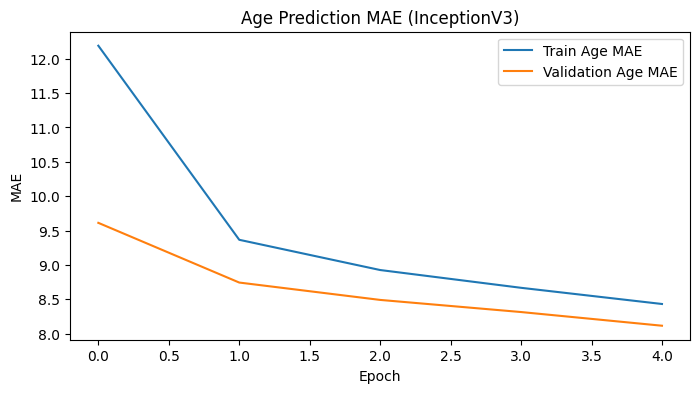

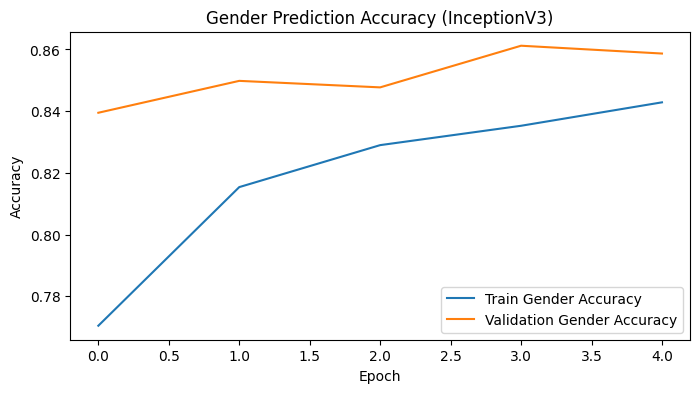

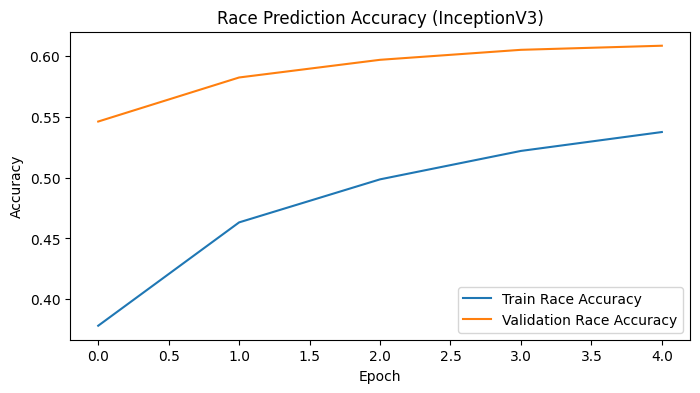

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(fine_tune_history_inception.history["age_mae"], label="Train Age MAE")
plt.plot(fine_tune_history_inception.history["val_age_mae"], label="Validation Age MAE")
plt.title("Age Prediction MAE (InceptionV3)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(fine_tune_history_inception.history["gender_accuracy"], label="Train Gender Accuracy")
plt.plot(fine_tune_history_inception.history["val_gender_accuracy"], label="Validation Gender Accuracy")
plt.title("Gender Prediction Accuracy (InceptionV3)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(fine_tune_history_inception.history["race_sparse_categorical_accuracy"], label="Train Race Accuracy")
plt.plot(fine_tune_history_inception.history["val_race_sparse_categorical_accuracy"], label="Validation Race Accuracy")
plt.title("Race Prediction Accuracy (InceptionV3)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [35]:
results_inception = I_model.evaluate(val_ds)
print("Evaluation Results for InceptionV3:", results_inception)

149/149 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - age_loss: 8.1041 - age_mae: 8.1157 - gender_accuracy: 0.8587 - gender_loss: 0.3311 - loss: 10.8092 - race_loss: 1.0375 - race_sparse_categorical_accuracy: 0.6087
Evaluation Results for InceptionV3: [10.80923843383789, 8.104108810424805, 0.33112016320228577, 1.0375210046768188, 8.115666389465332, 0.8586795926094055, 0.6087323427200317]


In [44]:
import pandas as pd
import numpy as np

# Extract the best EfficientNetB2 metrics from fine_tune_history
# The ModelCheckpoint saved the model based on 'val_loss', so we find the epoch with the minimum val_loss
# and use its corresponding metrics.
min_val_loss_epoch = np.argmin(fine_tune_history.history['val_loss'])
eff_val_age_mae = fine_tune_history.history['val_age_mae'][min_val_loss_epoch]
eff_val_gender_acc = fine_tune_history.history['val_gender_accuracy'][min_val_loss_epoch]
eff_val_race_acc = fine_tune_history.history['val_race_sparse_categorical_accuracy'][min_val_loss_epoch]

# Extract InceptionV3 results
inc_val_age_mae = results_inception[4]
inc_val_gender_acc = results_inception[5]
inc_val_race_acc = results_inception[6]

comparison_data = {
    "Metric": ["Validation Age MAE", "Validation Gender Accuracy", "Validation Race Accuracy"],
    "EfficientNetB2": [eff_val_age_mae, eff_val_gender_acc, eff_val_race_acc],
    "InceptionV3": [inc_val_age_mae, inc_val_gender_acc, inc_val_race_acc]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison (Corrected EfficientNetB2 Metrics):")
display(comparison_df)


Model Performance Comparison (Corrected EfficientNetB2 Metrics):


,Metric,EfficientNetB2,InceptionV3
0,Validation Age MAE,7.632863,8.115666
1,Validation Gender Accuracy,0.878928,0.858680
2,Validation Race Accuracy,0.620122,0.608732
